In [ ]:
# DSC680 Applied Data Science
# 11.1 Project 3: Milestone 3
# Mahad Farah

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [4]:
# 1. Load data
# -----------------------------
gold_url   = "https://datahub.io/core/gold-prices/_r/-/data/monthly.csv"
cpi_url    = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"
dgs10_url  = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10"
dxy_url    = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DTWEXBGS"
sp500_url  = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=SP500"
oil_url    = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILWTICO"

def load_gold_data(url):
    df = pd.read_csv(url)
    df.columns = ["date", "gold_price"]
    df["date"] = pd.to_datetime(df["date"])
    df["gold_price"] = pd.to_numeric(df["gold_price"], errors="coerce")
    return df

def load_fred_series(url, value_name):
    df = pd.read_csv(url)
    df.columns = ["date", value_name]
    df["date"] = pd.to_datetime(df["date"])
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    return df

gold  = load_gold_data(gold_url)
cpi   = load_fred_series(cpi_url, "cpi")
dgs10 = load_fred_series(dgs10_url, "dgs10")
dxy   = load_fred_series(dxy_url, "dxy")
sp500 = load_fred_series(sp500_url, "sp500")
oil   = load_fred_series(oil_url, "oil")

In [5]:
# 2. Convert higher-frequency FRED series to monthly averages
# -----------------------------
def to_monthly(df, value_col):
    out = df.set_index("date")[[value_col]].resample("M").mean().reset_index()
    return out

cpi_m   = to_monthly(cpi, "cpi")
dgs10_m = to_monthly(dgs10, "dgs10")
dxy_m   = to_monthly(dxy, "dxy")
sp500_m = to_monthly(sp500, "sp500")
oil_m   = to_monthly(oil, "oil")

# Gold is already monthly, but align to month-end for clean merging
gold["date"] = gold["date"].dt.to_period("M").dt.to_timestamp("M")

In [6]:
# 3. Merge data
# -----------------------------
df = (
    gold.merge(cpi_m, on="date", how="inner")
        .merge(dgs10_m, on="date", how="inner")
        .merge(dxy_m, on="date", how="inner")
        .merge(sp500_m, on="date", how="inner")
        .merge(oil_m, on="date", how="inner")
        .sort_values("date")
        .ffill()
        .dropna()
        .reset_index(drop=True)
)

In [7]:
# 4. Feature engineering
# -----------------------------
df["gold_return"] = df["gold_price"].pct_change()
df["cpi_inflation_mom"] = df["cpi"].pct_change()
df["sp500_return"] = df["sp500"].pct_change()
df["oil_return"] = df["oil"].pct_change()
df["dxy_return"] = df["dxy"].pct_change()

for col in ["gold_return", "cpi_inflation_mom", "dgs10", "dxy_return", "sp500_return", "oil_return"]:
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_lag2"] = df[col].shift(2)
    df[f"{col}_lag3"] = df[col].shift(3)

df["gold_vol_3m"] = df["gold_return"].rolling(3).std()
df["gold_ma_3m"] = df["gold_price"].rolling(3).mean()
df["gold_ma_12m"] = df["gold_price"].rolling(12).mean()

df["target_next_return"] = df["gold_return"].shift(-1)

model_df = df.dropna().copy()

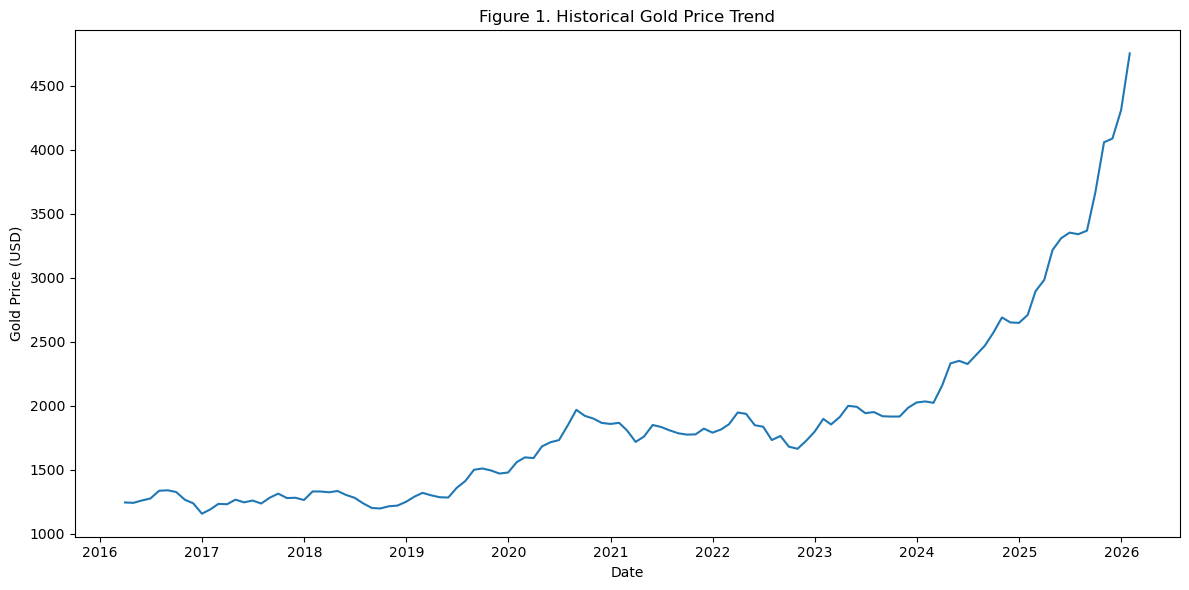

In [8]:
# Figure 1
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["gold_price"])
plt.title("Figure 1. Historical Gold Price Trend")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD)")
plt.tight_layout()
plt.show()

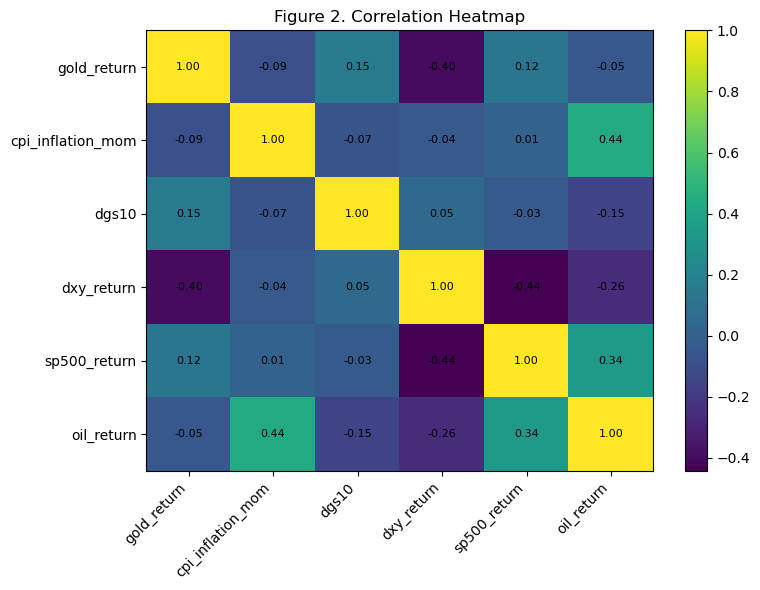

In [9]:
# Figure 2
# -----------------------------
corr_cols = ["gold_return", "cpi_inflation_mom", "dgs10", "dxy_return", "sp500_return", "oil_return"]
corr = model_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr, interpolation="nearest", aspect="auto")
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Figure 2. Correlation Heatmap")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
# 5. Train/test split for time series
# -----------------------------
feature_cols = [
    "gold_return_lag1", "gold_return_lag2", "gold_return_lag3",
    "cpi_inflation_mom_lag1", "cpi_inflation_mom_lag2", "cpi_inflation_mom_lag3",
    "dgs10_lag1", "dgs10_lag2", "dgs10_lag3",
    "dxy_return_lag1", "dxy_return_lag2", "dxy_return_lag3",
    "sp500_return_lag1", "sp500_return_lag2", "sp500_return_lag3",
    "oil_return_lag1", "oil_return_lag2", "oil_return_lag3",
    "gold_vol_3m"
]

X = model_df[feature_cols]
y = model_df["target_next_return"]

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = model_df["date"].iloc[split_idx:]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R²:", r2_score(y_test, y_pred))

MAE: 0.032968993905395344
RMSE: 0.04222069341517747
R²: -0.3816645146055


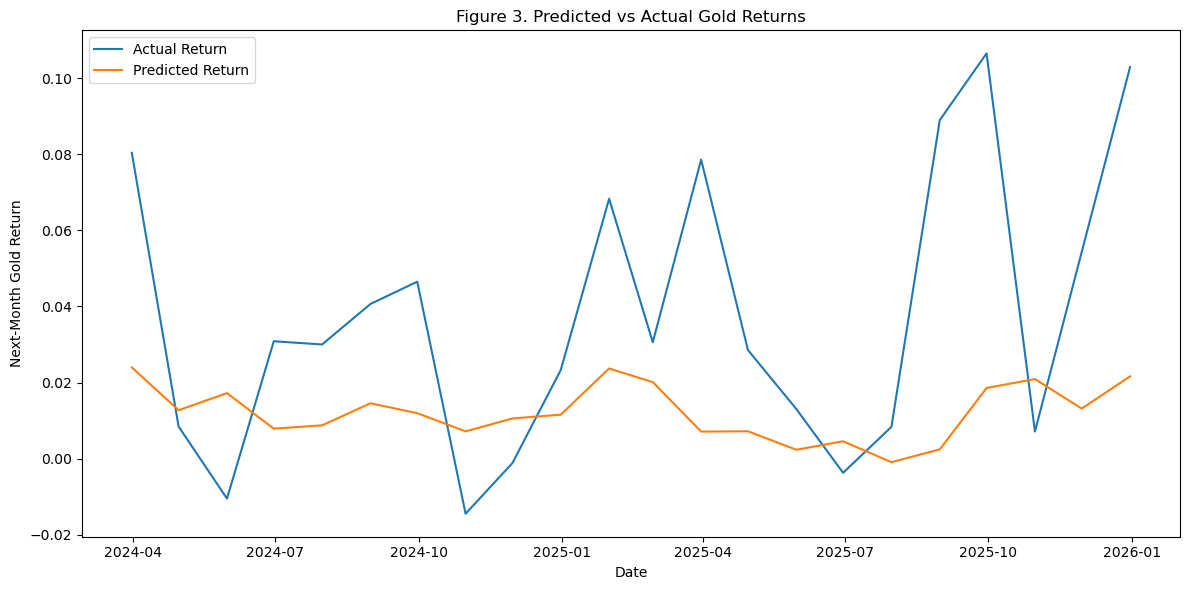

In [11]:
# Figure 3
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test.values, label="Actual Return")
plt.plot(dates_test, y_pred, label="Predicted Return")
plt.title("Figure 3. Predicted vs Actual Gold Returns")
plt.xlabel("Date")
plt.ylabel("Next-Month Gold Return")
plt.legend()
plt.tight_layout()
plt.show()


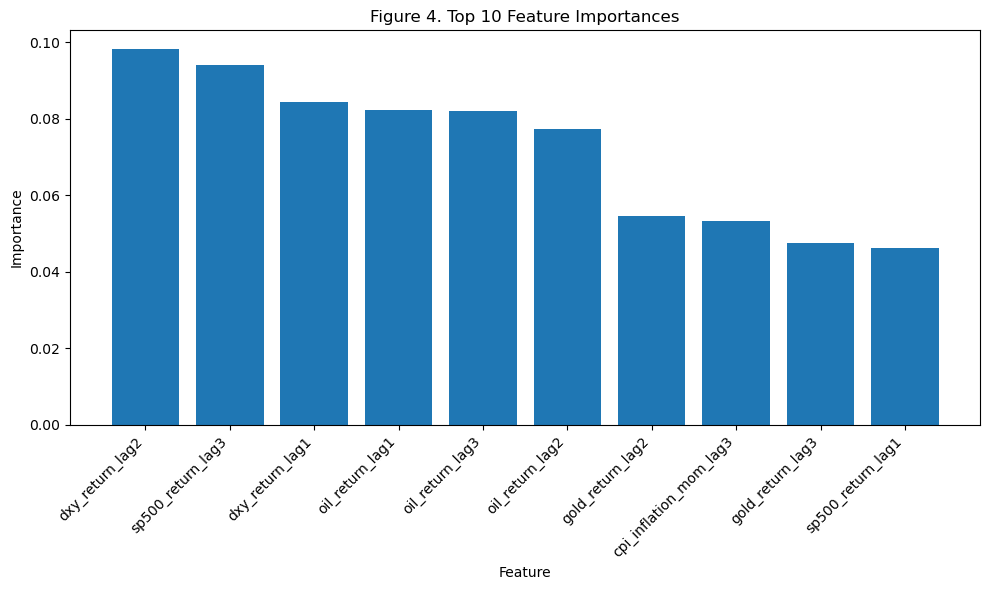

In [12]:
# Figure 4
# -----------------------------
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(importances.index, importances.values)
plt.title("Figure 4. Top 10 Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

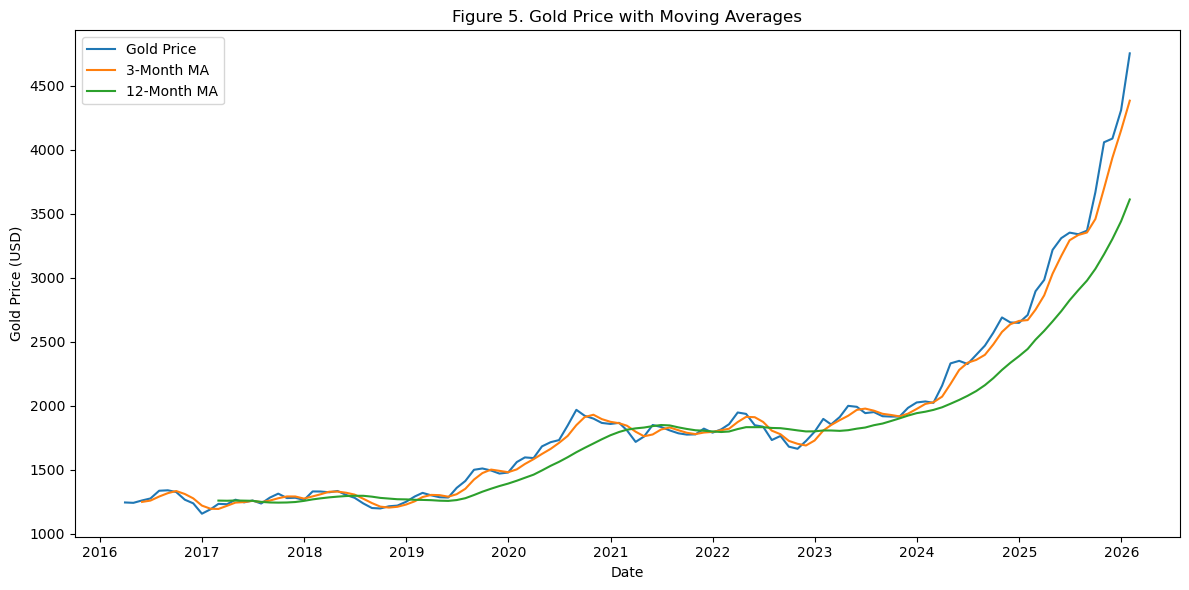

In [13]:
# Figure 5
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["gold_price"], label="Gold Price")
plt.plot(df["date"], df["gold_ma_3m"], label="3-Month MA")
plt.plot(df["date"], df["gold_ma_12m"], label="12-Month MA")
plt.title("Figure 5. Gold Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()